# ******Install Commands:******
Run these commands only once

In [ ]:
%pip install opencv-python Pillow
%pip install scipy scikit-fuzzy networkx
%pip install pytesseract pdf2image
%pip install transformers[torch] transformers
%pip install accelerate
%pip install tiktoken
%pip install sentencepiece
%pip install protobuf
%pip install --upgrade ipywidgets

In [ ]:
%pip install "numpy<2.0.0"

# Imports

In [1]:
# Model
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Image processing
import cv2
from PIL import Image
import pytesseract
from pdf2image import convert_from_path

# Others
import numpy as np
import copy
from pathlib import Path
import pandas as pd
import json
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import display

# Dataset Variable

In [2]:
# data_dir = "C:\\Users\\MOHAMMED EMAAN\\Downloads\\test"
# data_dir = "D:\\Documents\\Python\\Manam NNFL\\test"
data_dir = "/kaggle/input/the-rvlcdip-dataset-test/test"

# Image Preprocessing Module:

In [3]:
def preprocess_document_image(image_path):
    """
    Comprehensive preprocessing pipeline for document images
    """
    # Step 1: Read image
    img = cv2.imread(image_path)

    # Step 2: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 3: Noise reduction using Gaussian Blur
   # blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    blurred = gray
    # Step 4: Binarization using adaptive thresholding
    # Adaptive thresholding works better for uneven backgrounds
    binary = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # Step 5: Deskewing (correct rotation)
    coords = np.column_stack(np.where(binary > 0))
    angle = cv2.minAreaRect(coords)[-1]

    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    (h, w) = binary.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    deskewed = cv2.warpAffine(
        binary, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    # Step 6: Resize to standard dimensions (e.g., 224x224 or 384x384)
    #resized = cv2.resize(deskewed, (384, 384))

    return deskewed


# 1. CNN Classification Module:

In [4]:
class DocumentClassifier(nn.Module):
    """
    CNN architecture for document classification
    Classes: resumes, invoices, reports, contracts
    """

    def __init__(self, input_channels=1, num_classes=4):
        super(DocumentClassifier, self).__init__()

        # Convolutional Block 1
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3,
                              padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout(0.25)

        # Convolutional Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout(0.25)

        # Convolutional Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop3 = nn.Dropout(0.3)

        # Convolutional Block 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))

        # Fully Connected Layers
        self.fc1 = nn.Linear(256, 128)
        self.drop4 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.drop5 = nn.Dropout(0.5)
        self.fc_out = nn.Linear(64, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.drop1(x)

        # Block 2
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = self.drop2(x)

        # Block 3
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = self.drop3(x)

        # Block 4
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten

        # Fully Connected Layers
        x = self.relu(self.fc1(x))
        x = self.drop4(x)
        x = self.relu(self.fc2(x))
        x = self.drop5(x)
        x = self.fc_out(x)

        return x


# Initialize model
model_CNN = DocumentClassifier(input_channels=1, num_classes=4)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_CNN.parameters())

# Print model summary
print(model_CNN)
print("\n" + "="*50)
print("Model Summary")
print("="*50)
total_params = sum(p.numel() for p in model_CNN.parameters())
trainable_params = sum(p.numel() for p in model_CNN.parameters() if p.requires_grad)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

DocumentClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop3): Dropout(p=0.3, inplace=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2

# Additional Preprocessing (Rotation)

In [7]:
import pandas as pd

CSV_PATH = "/kaggle/input/ocr-csv-file/orientation.csv"  # change to your csv path

df = pd.read_csv(CSV_PATH)  # e.g. columns: image_path, angle
angle_map = dict(zip(df["ImagePath"], df["Rotate"]))
base_dir = "/kaggle/input/the-rvlcdip-dataset-test/"

#Function

import os

def rotate_image_by_csv(image_path):
    """
    image_path: path string exactly as it appears in the CSV (key in angle_map)
    base_dir: optional base folder to prepend (e.g. /kaggle/input/your-dataset)
    """
    # Look up angle (default 0 if not found)
    angle = int(angle_map.get(image_path, 0))

    # Build full path on disk
    if base_dir:
        full_path = os.path.join(base_dir, image_path)
    else:
        full_path = image_path

    img = Image.open(full_path)

    if angle == 0:
        rotated = img
    elif angle == 90:
        rotated = img.transpose(Image.ROTATE_90)
    elif angle == 180:
        rotated = img.transpose(Image.ROTATE_180)
    elif angle == 270:
        rotated = img.transpose(Image.ROTATE_270)
    else:
        rotated = img  # safety fallback

    return rotated

# **1.1 Trainng Module for CNN:**

# **1.1.1 Validating dataset**

In [8]:
def custom_is_valid_file(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

BLACKLIST = [
    "2500126531_2500126536.tif",
]

def check_blacklist(path):
    for entry in BLACKLIST:
        if entry in path:
            return False
    return True

# 1.1.2 Importing Datasets and Initializing Model:

In [9]:
# Load training data
# data_dir is defined at the start of the notebook.

RESOLUTION = 512
BATCH_SIZE = 60

# Data augmentation and preprocessing
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomAffine(degrees=0, shear=0.1),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load dataset with validation transform first to check classes
full_dataset_val = datasets.ImageFolder(data_dir, transform=val_transform, is_valid_file=check_blacklist, loader=rotate_image_by_csv)

# Get number of classes
num_classes = len(full_dataset_val.classes)
print(f"Number of classes detected: {num_classes}")
print(f"Classes: {full_dataset_val.classes}")

# Get total number of samples
total_samples = len(full_dataset_val)
#limit = 5000
limit = total_samples
train_size = int(0.8 * limit)
val_size = limit - train_size

# Create shuffled indices for proper splitting
indices = np.arange(total_samples)
np.random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:limit]

# Create datasets with proper transforms
full_dataset_train = datasets.ImageFolder(data_dir, transform=train_transform, is_valid_file=check_blacklist, loader=rotate_image_by_csv)
train_dataset = Subset(full_dataset_train, train_indices)
val_dataset = Subset(full_dataset_val, val_indices)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

validation_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)



Number of classes detected: 16
Classes: ['advertisement', 'budget', 'email', 'file_folder', 'form', 'handwritten', 'invoice', 'letter', 'memo', 'news_article', 'presentation', 'questionnaire', 'resume', 'scientific_publication', 'scientific_report', 'specification']
Train samples: 31996, Val samples: 8000


# **1.1.3 Model setup:**

In [10]:
# Model
# Early Stopping callback
class EarlyStopping:
    def __init__(self, patience=10, restore_best_weights=True):
        self.patience = patience
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_loss = None
        self.best_weights = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            if self.restore_best_weights:
                self.best_weights = copy.deepcopy(model.state_dict())
        elif val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def restore_model(self, model):
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)


# Model Checkpoint callback
class ModelCheckpoint:
    def __init__(self, filepath, monitor='val_accuracy', save_best_only=True, mode='max'):
        self.filepath = filepath
        self.monitor = monitor
        self.save_best_only = save_best_only
        self.mode = mode
        self.best_value = None

    def __call__(self, val_metric, model):
        if self.best_value is None:
            self.best_value = val_metric
            self.save_model(model)
        elif self.mode == 'max' and val_metric > self.best_value:
            self.best_value = val_metric
            self.save_model(model)
        elif self.mode == 'min' and val_metric < self.best_value:
            self.best_value = val_metric
            self.save_model(model)

    def save_model(self, model):
        torch.save(model.state_dict(), self.filepath)
        print(f"Model saved to {self.filepath}")


# ---


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model with correct number of classes
model_CNN = DocumentClassifier(input_channels=1, num_classes=num_classes)
model_CNN.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_CNN.parameters())

# Initialize callbacks
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    'best_model.pth',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)


# Training functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        batch_accuracy = 100 * correct / total if total > 0 else 0.0
        if i % 10 == 0:
            print(f"    Training batch #{i+1} done. Accuracy: {batch_accuracy}%")

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total if total > 0 else 0.0

    return epoch_loss, epoch_accuracy

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            batch_accuracy = 100 * correct / total if total > 0 else 0.0
            if i % 10 == 0:
                print(f"    Validation batch #{i+1} done. Accuracy: {batch_accuracy}%")

    epoch_loss = running_loss / len(val_loader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy


Using device: cuda


# 1.1.4 Training Process:

In [11]:
history = {'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}

In [13]:
# Train model
num_epochs = 5  # Increased from 1 to allow early stopping to work

print("\nStarting training...")
print("=" * 60)

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}:")
    # Training phase
    print("    Train step...")
    train_loss, train_accuracy = train_epoch(model_CNN, train_loader, criterion, optimizer, device)
    print("    Train step done\n")

    # Validation phase
    print("    Validation step...")
    val_loss, val_accuracy = validate_epoch(model_CNN, validation_loader, criterion, device)
    print("    Validation step done")

    # Store history
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')
    print('-' * 60)

    # Callbacks
    checkpoint(val_accuracy, model_CNN)
    early_stop(val_loss, model_CNN)

    if early_stop.early_stop:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        early_stop.restore_model(model_CNN)
        break

print("=" * 60)
print("\nTraining completed!")


Starting training...
Epoch 1:
    Train step...
    Training batch #1 done. Accuracy: 23.333333333333332%
    Training batch #11 done. Accuracy: 29.696969696969695%
    Training batch #21 done. Accuracy: 30.317460317460316%
    Training batch #31 done. Accuracy: 31.612903225806452%
    Training batch #41 done. Accuracy: 31.910569105691057%
    Training batch #51 done. Accuracy: 31.96078431372549%
    Training batch #61 done. Accuracy: 32.021857923497265%
    Training batch #71 done. Accuracy: 31.854460093896712%
    Training batch #81 done. Accuracy: 32.13991769547325%
    Training batch #91 done. Accuracy: 32.234432234432234%
    Training batch #101 done. Accuracy: 32.04620462046205%
    Training batch #111 done. Accuracy: 32.027027027027025%
    Training batch #121 done. Accuracy: 32.011019283746556%
    Training batch #131 done. Accuracy: 32.03562340966921%
    Training batch #141 done. Accuracy: 32.174940898345156%
    Training batch #151 done. Accuracy: 31.96467991169978%
    Tra

In [14]:
print(history)
print(len(history["val_accuracy"]))

{'train_loss': [2.7047683518477594, 2.4979570103941784, 2.3817586086216043, 2.326499592052417, 2.292813480570075, 2.2548781439159695, 2.2383669440665943, 2.222077343571052, 2.2053483880860973, 2.182513130961286, 2.1675857149259876, 2.147152494178729, 2.1410832768968877, 2.129833418778266, 2.1156221529964205, 2.1008844415793257, 2.0965118660462485, 2.084961846303404, 2.071820843755529, 2.075778086980184, 2.0615406344445906, 2.0522132279274614, 2.039984664890204, 2.0297769794749856, 2.024316864067249, 2.022184176168192, 2.0099360320005526, 2.0005838207984237, 1.9939173122916776, 1.9866263832938804], 'train_accuracy': [10.30128766095762, 17.924115514439304, 20.799474934366796, 22.115264408051008, 23.252906613326665, 23.81235154394299, 24.449931241405174, 24.649956244530568, 25.653206650831354, 25.8126015751969, 26.178272284035504, 27.34404300537567, 27.272159019877485, 27.69721215151894, 28.772346543317916, 29.081760220027505, 29.54431803975497, 29.56932116514564, 30.26940867608451, 30.21

# 2. OCR for Text Extraction:

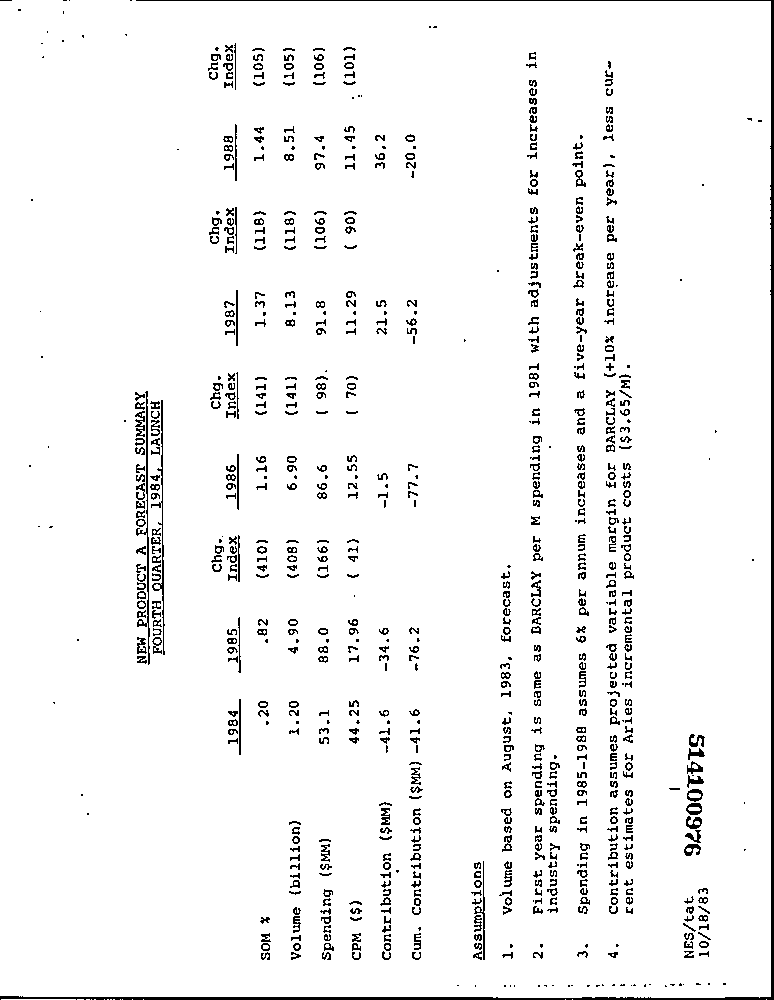

' \n\nChg. cha. Chg, chg.\n1984 1985. Index _1986 Index _1987 Index _1984 index\n\nSOM % -20 282 (410) 1.16 (141) 1.37 (118) 1.44 (105)\nVolume (billion) 2.20 4.90 (408) 6.90 (141) 8.13 (118) 8.51 (105)\nSpending ($MM) 53.1 88.0 66) 86.6 (98), 91.8 (a06) 97.4 (106)\ncpm ($) 44,25 17.96 (42) 12.55 ( 70) 11.29 ( 90) 11,45. (101)\nContribution ($HM) ~Al.6  -34.6 “1.5 21.5 36.2\n\nCum. Contribution ($MM) -41.6  ~76.2 -7h.7 -56.2 -20.0\n\nAssumptions\n1. Volume based on August, 1983, forecast,\n\n2. First year spending is same as BARCLAY per M spending in 1981 with adjustments for increases in\nindustry spending. :\n\n3. Spending in 1985-1988 assumes 6% per annum increases and 3 five-year break-even point.\n\n \n\n4. Contribution assumes projected variable margin for BARCLAY (+10% increase per year), less cur~\nrent estimates for Aries incremental product costs ($3.65/M).\n\n1\nNBe/toe 5 %#600TPTS\n\n \n \n\n \n\x0c'

In [31]:
def extract_text_from_document(image_path,displayimage=False):
    """
    Extract text from preprocessed document image
    """
    # Preprocess image
    processed_img = preprocess_document_image(image_path)

    # Convert numpy array to PIL Image
    pil_img = Image.fromarray(processed_img)
    if displayimage :
        display(pil_img)

    # Apply OCR
    text = pytesseract.image_to_string(
        pil_img,
        config='--psm 1 --oem 3'  # Automatic page segmentation with LSTM
    )

    return text

extract_text_from_document("/kaggle/input/the-rvlcdip-dataset-test/test/budget/0000011677.tif",True)

# OCR to CSV:

In [ ]:
data_dir = "D:\\Documents\\Python\\Manam NNFL\\test"
path_out = "ocr.csv"

def process_image_ocr(path_label_tuple: tuple[str, int]):
    image_path, label = path_label_tuple
    text = extract_text_from_document(image_path, False)
    return image_path, label, text

dataset = datasets.ImageFolder(data_dir, loader=extract_text_from_document)
classes = dataset.classes
path_label_list = [(path, label) for path, label in dataset.imgs]

# (Image Path, Label, Text)
entries_ocr: list[tuple[str, str, str]] = []

print(list(enumerate(classes)))

with ThreadPoolExecutor(max_workers=15) as executor, open(path_out, "w", newline="", encoding="utf-8") as f:
    futures = [executor.submit(process_image_ocr, path_label) for path_label in path_label_list]
    writer = csv.writer(f)
    writer.writerow(["ImagePath", "Label", "Text"])

    for future in tqdm(as_completed(futures), total=len(futures), desc="OCR progress"):
        image_path, label, text = future.result()
        image_path = image_path.replace("D:\\Documents\\Python\\Manam NNFL\\test\\", "test/").replace("\\", "/", 1)
        label = classes[int(label)]
        text = text.strip()

        row = (image_path, label, text)
        entries_ocr.append(row)
        writer.writerow(row)

# Orientation Detection CSV:

In [ ]:
data_dir = "D:\\Documents\\Python\\Manam NNFL\\test"
path_out = "orientation.csv"

def process_image_orientation(path_label_tuple: tuple[str, str]):
    image_path, label = path_label_tuple
    rotate = extract_orientation_from_document(image_path)
    return image_path, label, rotate

dataset = datasets.ImageFolder(data_dir)
classes = dataset.classes
path_label_list = [(path, classes[label]) for path, label in dataset.imgs]

# (Image Path, Label, Rotate)
entries_orientation: list[tuple[str, str, str]] = []

print(list(enumerate(classes)))

with ThreadPoolExecutor(max_workers=15) as executor, open(path_out, "w", newline="", encoding="utf-8") as f:
    futures = [executor.submit(process_image_orientation, path_label) for path_label in path_label_list]
    writer = csv.writer(f)
    writer.writerow(["ImagePath", "Label", "Rotate"])

    for future in tqdm(as_completed(futures), total=len(futures), desc="Orientation progress"):
        image_path, label, rotate = future.result()
        image_path = image_path.replace("D:\\Documents\\Python\\Manam NNFL\\test\\", "test/").replace("\\", "/", 1)
        # label = classes[int(label)]

        row = (image_path, label, str(rotate))
        entries_orientation.append(row)
        writer.writerow(row)


# 3. LSTM Classification Module:

In [16]:
class LSTMTextClassifier(nn.Module):
    """
    LSTM for document classification based on OCR text
    """
    def __init__(self, vocab_size=5000, embedding_dim=128, 
                 hidden_dim=256, num_classes=16):
        super(LSTMTextClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, 
            num_layers=2, 
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(embedded)
        
        # Concatenate final hidden states from both directions
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        dropped = self.dropout(hidden_cat)
        output = self.fc(dropped)
        
        return output


class SimpleTextTokenizer:
    """
    Simple word-level tokenizer for LSTM
    """
    def __init__(self, vocab_size=5000, max_length=512):
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
    
    def build_vocab(self, texts):
        """Build vocabulary from list of texts"""
        word_freq = Counter()
        for text in texts:
            words = text.lower().split()
            word_freq.update(words)
        
        # Take most common words
        for word, _ in word_freq.most_common(self.vocab_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
    
    def encode(self, text):
        """Convert text to tensor"""
        words = text.lower().split()[:self.max_length]
        indices = [self.word2idx.get(word, 1) for word in words]
        
        # Pad
        if len(indices) < self.max_length:
            indices += [0] * (self.max_length - len(indices))
        
        return torch.tensor([indices], dtype=torch.long)

# Model Setup:

In [18]:
# DATASET CLASSES
# ============================================================================

class OCRTextDataset(Dataset):
    """Custom dataset for OCR text classification"""
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Encode text
        words = text.lower().split()[:self.max_length]
        indices = [self.tokenizer.word2idx.get(word, 1) for word in words]

        # Pad or truncate
        if len(indices) < self.max_length:
            indices += [0] * (self.max_length - len(indices))
        else:
            indices = indices[:self.max_length]

        return {
            'text': torch.tensor(indices, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }


# ============================================================================
# TRAINER CLASS
# ============================================================================

class LSTMTrainer:
    """Training pipeline for LSTM text classifier"""
    def __init__(self, model, device='cpu', save_dir='./models'):
        self.model = model
        self.device = device
        self.model.to(device)
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)

        # Training history
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': []
        }

    def train_epoch(self, train_loader, optimizer, criterion):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch in train_loader:
            texts = batch['text'].to(self.device)
            labels = batch['label'].to(self.device)

            # Forward pass
            optimizer.zero_grad()
            outputs = self.model(texts)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_loss += loss.item()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        accuracy = correct / total

        return avg_loss, accuracy

    def validate(self, val_loader, criterion):
        """Validate model"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in val_loader:
                texts = batch['text'].to(self.device)
                labels = batch['label'].to(self.device)

                outputs = self.model(texts)
                loss = criterion(outputs, labels)

                _, predicted = torch.max(outputs.data, 1)
                total_loss += loss.item()
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        avg_loss = total_loss / len(val_loader)
        accuracy = correct / total

        return avg_loss, accuracy

    def train(self, train_loader, val_loader, epochs=20, learning_rate=0.001, 
              patience=5, weight_decay=1e-5):
        """Complete training loop with early stopping"""
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), 
                              lr=learning_rate, 
                              weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2, verbose=True
        )

        best_val_loss = float('inf')
        patience_counter = 0

        print(f"Starting training on {self.device}...")
        print(f"Epochs: {epochs}, Learning Rate: {learning_rate}")
        print("-" * 60)

        for epoch in range(epochs):
            # Train
            train_loss, train_acc = self.train_epoch(train_loader, optimizer, criterion)

            # Validate
            val_loss, val_acc = self.validate(val_loader, criterion)

            # Store history
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            # Print progress
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
            print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

            # Learning rate scheduling
            scheduler.step(val_loss)

            # Early stopping with checkpoint saving
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                self.save_checkpoint('best_model.pt', epoch)
                print(f"  ✓ Best model saved (Val Loss: {val_loss:.4f})")
            else:
                patience_counter += 1
                print(f"  ⚠ No improvement ({patience_counter}/{patience})")

            print("-" * 60)

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        print("Training completed!")
        return self.history

    def save_checkpoint(self, filename, epoch):
        """Save model checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'timestamp': datetime.now().isoformat()
        }
        path = self.save_dir / filename
        torch.save(checkpoint, path)

    def save_model(self, filename='trained_model.pt'):
        """Save trained model weights"""
        path = self.save_dir / filename
        torch.save(self.model.state_dict(), path)
        print(f"✓ Model weights saved to {path}")
        return path

    def load_model(self, filename='best_model.pt'):
        """Load trained model"""
        path = self.save_dir / filename
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint)
        print(f"✓ Model loaded from {path}")

    def plot_history(self, save_path=None):
        """Plot training history"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Loss plot
        axes[0].plot(self.history['train_loss'], label='Train Loss', marker='o')
        axes[0].plot(self.history['val_loss'], label='Val Loss', marker='s')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy plot
        axes[1].plot(self.history['train_acc'], label='Train Accuracy', marker='o')
        axes[1].plot(self.history['val_acc'], label='Val Accuracy', marker='s')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training and Validation Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path)
            print(f"✓ Plot saved to {save_path}")
        plt.show()


# ============================================================================
# EVALUATION FUNCTION
# ============================================================================

def evaluate_model(model, test_loader, device, num_classes=16):
    """Evaluate model on test set with detailed metrics"""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            texts = batch['text'].to(device)
            labels = batch['label'].to(device)

            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)

    print("\n" + "="*60)
    print("EVALUATION RESULTS")
    print("="*60)
    print(f"Overall Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    return all_preds, all_labels

# Training:

LSTM TEXT CLASSIFIER TRAINING

[STEP 1] Loading Data...
  Total samples: 39996
  Train: 25596, Val: 6400, Test: 8000

[STEP 2] Building Tokenizer...
  Vocabulary size: 5000

[STEP 3] Creating Datasets...
  Train DataLoader: 800 batches
  Val DataLoader: 200 batches
  Test DataLoader: 250 batches

[STEP 4] Initializing Model...
  Device: cuda
  Model parameters: 3,015,696

[STEP 5] Training Model...
Starting training on cuda...
Epochs: 20, Learning Rate: 0.001
------------------------------------------------------------


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/20]
  Train Loss: 1.8937 | Train Acc: 0.4032
  Val Loss:   1.4425 | Val Acc:   0.5475
  ✓ Best model saved (Val Loss: 1.4425)
------------------------------------------------------------
Epoch [2/20]
  Train Loss: 1.3123 | Train Acc: 0.6028
  Val Loss:   1.2123 | Val Acc:   0.6400
  ✓ Best model saved (Val Loss: 1.2123)
------------------------------------------------------------
Epoch [3/20]
  Train Loss: 1.0681 | Train Acc: 0.6807
  Val Loss:   1.0736 | Val Acc:   0.6773
  ✓ Best model saved (Val Loss: 1.0736)
------------------------------------------------------------
Epoch [4/20]
  Train Loss: 0.9182 | Train Acc: 0.7274
  Val Loss:   1.0293 | Val Acc:   0.6928
  ✓ Best model saved (Val Loss: 1.0293)
------------------------------------------------------------
Epoch [5/20]
  Train Loss: 0.7996 | Train Acc: 0.7607
  Val Loss:   0.9993 | Val Acc:   0.7069
  ✓ Best model saved (Val Loss: 0.9993)
------------------------------------------------------------
Epoch [6/20]
  Train

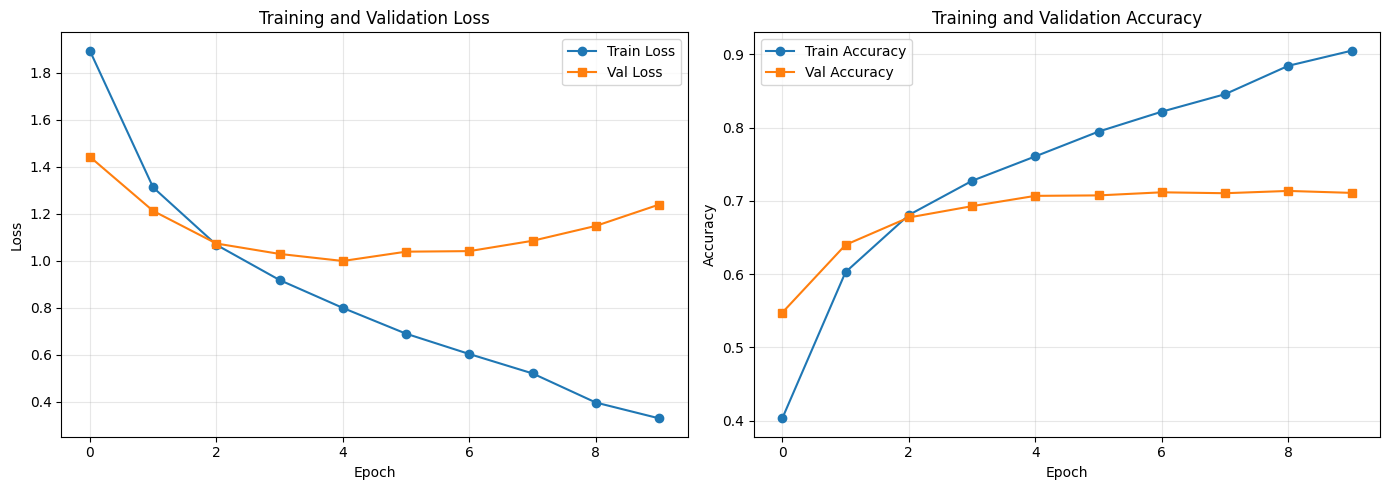


✓ TRAINING PIPELINE COMPLETED!

Model weights saved in: ./lstm_models/
  - best_model.pt (best checkpoint)
  - final_lstm_model.pt (final trained weights)
  - training_history.png (loss/accuracy curves)


In [19]:
# ============================================================================
# MAIN TRAINING FUNCTION
# ============================================================================

print("="*60)
print("LSTM TEXT CLASSIFIER TRAINING")
print("="*60)

CLASS_NAMES = sorted([
    'letter', 'form', 'email', 'handwritten', 'advertisement',
    'scientific_report', 'scientific_publication', 'specification',
    'file_folder', 'news_article', 'budget', 'invoice',
    'presentation', 'questionnaire', 'resume', 'memo'
])

# ========== STEP 1: LOAD YOUR DATA ==========
print("\n[STEP 1] Loading Data...")

# REPLACE THESE WITH YOUR ACTUAL DATA
sample_texts = []
sample_labels = []

csv_path = "/kaggle/input/ocr-csv-file/ocr.csv"
df = pd.read_csv(csv_path)
total_samples = len(df)
#limit = 5000
limit = total_samples

df["Label"] = df["Label"].map(lambda x: CLASS_NAMES.index(x))
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.head(limit)
sample_texts = df["Text"].astype(str).tolist()
sample_labels = df["Label"].astype(int).tolist()

print(f"  Total samples: {len(sample_texts)}")

# Split data
texts_train, texts_test, labels_train, labels_test = train_test_split(
    sample_texts, sample_labels, 
    test_size=0.2, random_state=42, stratify=sample_labels
)

texts_train, texts_val, labels_train, labels_val = train_test_split(
    texts_train, labels_train, 
    test_size=0.2, random_state=42, stratify=labels_train
)

print(f"  Train: {len(texts_train)}, Val: {len(texts_val)}, Test: {len(texts_test)}")

# ========== STEP 2: BUILD TOKENIZER ==========
print("\n[STEP 2] Building Tokenizer...")

tokenizer = SimpleTextTokenizer(vocab_size=5000, max_length=512)
tokenizer.build_vocab(texts_train)
print(f"  Vocabulary size: {len(tokenizer.word2idx)}")

# ========== STEP 3: CREATE DATASETS ==========
print("\n[STEP 3] Creating Datasets...")

train_dataset = OCRTextDataset(texts_train, labels_train, tokenizer)
val_dataset = OCRTextDataset(texts_val, labels_val, tokenizer)
test_dataset = OCRTextDataset(texts_test, labels_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"  Train DataLoader: {len(train_loader)} batches")
print(f"  Val DataLoader: {len(val_loader)} batches")
print(f"  Test DataLoader: {len(test_loader)} batches")

# ========== STEP 4: INITIALIZE MODEL ==========
print("\n[STEP 4] Initializing Model...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Device: {device}")

model_lstm = LSTMTextClassifier(
    vocab_size=5000,
    embedding_dim=128,
    hidden_dim=256,
    num_classes=16
)

print(f"  Model parameters: {sum(p.numel() for p in model_lstm.parameters()):,}")

# ========== STEP 5: TRAIN MODEL ==========
print("\n[STEP 5] Training Model...")

trainer = LSTMTrainer(model_lstm, device=device, save_dir='./lstm_models')
history_lstm = trainer.train(
    train_loader, val_loader,
    epochs=20,
    learning_rate=0.001,
    patience=5,
    weight_decay=1e-5
)

# ========== STEP 6: SAVE WEIGHTS ==========
print("\n[STEP 6] Saving Model Weights...")

trainer.save_model('final_lstm_model.pt')
trainer.save_model('best_model.pt')

# ========== STEP 7: EVALUATE ==========
print("\n[STEP 7] Evaluating Model...")

trainer.load_model('best_model.pt')
preds, labels = evaluate_model(model_lstm, test_loader, device)

# ========== STEP 8: PLOT RESULTS ==========
print("\n[STEP 8] Plotting Training History...")

trainer.plot_history(save_path='./lstm_models/training_history.png')

print("\n" + "="*60)
print("✓ TRAINING PIPELINE COMPLETED!")
print("="*60)
print("\nModel weights saved in: ./lstm_models/")
print("  - best_model.pt (best checkpoint)")
print("  - final_lstm_model.pt (final trained weights)")
print("  - training_history.png (loss/accuracy curves)")

# 4. Fuzzy Classification Module:

In [20]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import torch.nn.functional as F

class IntegratedFuzzySystem:
    """
    Fuzzy inference system combining CNN and LSTM predictions
    """
    def __init__(self):
        self.setup_fuzzy_system()
    
    def setup_fuzzy_system(self):
        """Create fuzzy logic system with CNN and LSTM inputs"""
        
        # Input variables
        cnn_conf = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'cnn_confidence')
        lstm_conf = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'lstm_confidence')
        
        # Output variable
        certainty = ctrl.Consequent(np.arange(0, 1.01, 0.01), 'certainty')
        
        # Membership functions
        cnn_conf['low'] = fuzz.trimf(cnn_conf.universe, [0, 0, 0.5])
        cnn_conf['medium'] = fuzz.trimf(cnn_conf.universe, [0.3, 0.5, 0.7])
        cnn_conf['high'] = fuzz.trimf(cnn_conf.universe, [0.6, 1, 1])
        
        lstm_conf['low'] = fuzz.trimf(lstm_conf.universe, [0, 0, 0.5])
        lstm_conf['medium'] = fuzz.trimf(lstm_conf.universe, [0.3, 0.5, 0.7])
        lstm_conf['high'] = fuzz.trimf(lstm_conf.universe, [0.6, 1, 1])
        
        certainty['uncertain'] = fuzz.trimf(certainty.universe, [0, 0, 0.4])
        certainty['moderate'] = fuzz.trimf(certainty.universe, [0.3, 0.5, 0.7])
        certainty['certain'] = fuzz.trimf(certainty.universe, [0.6, 1, 1])
        
        # Fuzzy rules
        rule1 = ctrl.Rule(cnn_conf['high'] & lstm_conf['high'], certainty['certain'])
        rule2 = ctrl.Rule(cnn_conf['high'] & lstm_conf['medium'], certainty['moderate'])
        rule3 = ctrl.Rule(cnn_conf['medium'] & lstm_conf['high'], certainty['moderate'])
        rule4 = ctrl.Rule(cnn_conf['medium'] & lstm_conf['medium'], certainty['moderate'])
        rule5 = ctrl.Rule(cnn_conf['low'] | lstm_conf['low'], certainty['uncertain'])
        rule6 = ctrl.Rule(cnn_conf['high'] & lstm_conf['low'], certainty['moderate'])
        rule7 = ctrl.Rule(cnn_conf['low'] & lstm_conf['high'], certainty['moderate'])
        
        self.fuzzy_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
        self.fuzzy_system = ctrl.ControlSystemSimulation(self.fuzzy_ctrl)
    
    def classify(self, cnn_logits, lstm_logits):
        """
        Combine CNN and LSTM predictions using fuzzy logic
        
        Returns: dict with classification results
        """
        # Convert logits to probabilities
        cnn_probs = F.softmax(cnn_logits, dim=-1).squeeze().cpu().numpy()
        lstm_probs = F.softmax(lstm_logits, dim=-1).squeeze().cpu().numpy()
        
        # Get predictions and confidences
        cnn_pred = np.argmax(cnn_probs)
        cnn_confidence = cnn_probs[cnn_pred]
        
        lstm_pred = np.argmax(lstm_probs)
        lstm_confidence = lstm_probs[lstm_pred]
        
        # Apply fuzzy logic
        self.fuzzy_system.input['cnn_confidence'] = float(cnn_confidence)
        self.fuzzy_system.input['lstm_confidence'] = float(lstm_confidence)
        self.fuzzy_system.compute()
        
        fuzzy_certainty = self.fuzzy_system.output['certainty']
        
        # Final decision
        if cnn_pred == lstm_pred:
            final_class = cnn_pred
            agreement = True
        else:
            # Choose based on higher confidence
            final_class = cnn_pred if cnn_confidence > lstm_confidence else lstm_pred
            agreement = False
        
        # Decision description
        if fuzzy_certainty < 0.4:
            decision = "UNCERTAIN - Requires human review"
        elif fuzzy_certainty < 0.7:
            decision = "MODERATE confidence"
        else:
            decision = "HIGH confidence"
        
        return {
            'cnn_prediction': int(cnn_pred),
            'cnn_confidence': float(cnn_confidence),
            'lstm_prediction': int(lstm_pred),
            'lstm_confidence': float(lstm_confidence),
            'models_agree': agreement,
            'final_prediction': int(final_class),
            'fuzzy_certainty': float(fuzzy_certainty),
            'decision': decision,
            'cnn_probs': cnn_probs.tolist(),
            'lstm_probs': lstm_probs.tolist()
        }

# 5. Document Summarization:

In [21]:
# First, download the model to cache it properly
import os
from transformers import BartTokenizer, BartForConditionalGeneration
import torch

print("Step 1: Downloading and caching model... This may take 10-15 minutes...")

# Set a specific cache directory to avoid conflicts
cache_dir = "./bart_cache"  # Local folder for model files
os.makedirs(cache_dir, exist_ok=True)

# Download without local_files_only to populate cache
try:
    print("Downloading tokenizer...")
    tokenizer = BartTokenizer.from_pretrained(
        'facebook/bart-large-cnn',
        cache_dir=cache_dir,
        local_files_only=False  # Allow download
    )
    print("Tokenizer downloaded successfully!")

    print("Downloading model...")
    model_Summ = BartForConditionalGeneration.from_pretrained(
        'facebook/bart-large-cnn',
        cache_dir=cache_dir,
        local_files_only=False  # Allow download
    )
    print("Model downloaded successfully!")

    # Save to local folder for future use
    tokenizer.save_pretrained(f"{cache_dir}/tokenizer")
    model_Summ.save_pretrained(f"{cache_dir}/model")

    print(f"\n✓ Model cached to: {cache_dir}")
    print("You can now use local_files_only=True or load from the local folder.")

except Exception as e:
    print(f"Download failed: {e}")
    print("Try running: pip install --upgrade transformers torch")

2025-12-07 06:50:23.537041: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765090223.713964     145 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765090223.764045     145 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Model downloaded successfully!


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3685: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(



✓ Model cached to: ./bart_cache
You can now use local_files_only=True or load from the local folder.


# Sumarizer Class:

In [22]:
import os
from transformers import BartTokenizer, BartForConditionalGeneration
import torch
class DocumentSummarizer:
    def __init__(self):
        """
        Initialize multilingual translator using mBART-50
        Supports 50+ languages
        """
        self.model =  BartForConditionalGeneration.from_pretrained(
        'facebook/bart-large-cnn',
        cache_dir=cache_dir,
        local_files_only=False  # Allow download
    )
        self.tokenizer = BartTokenizer.from_pretrained(
        'facebook/bart-large-cnn',
        cache_dir=cache_dir,
        local_files_only=False  # Allow download
    )


    def summarize(self, text, max_length=150, min_length=50):
        """
        Summarize input text using BART model
    
        Parameters:
        - text: Input text to summarize (str)
        - max_length: Maximum summary length in tokens (default: 150)
        - min_length: Minimum summary length in tokens (default: 50)
    
        Returns:
        - summary: Summarized text (str)
        - stats: Dictionary with original/summary lengths and compression ratio
    
        Example:
        >>> summarizer = DocumentSummarizer()
        >>> text = "Long document here..."
        >>> summary, stats = summarizer.summarize(text)
        >>> print(summary)
        >>> print(f"Compression: {stats['compression_ratio']}")
        """
    
    # Input validation
        if not text or len(text.strip()) == 0:
            raise ValueError("Input text cannot be empty")
    
        if len(text.split()) < 20:
            raise ValueError("Text too short. Minimum 20 words required for summarization")
    
        try:
            # Tokenize input text with truncation for long documents
            inputs = self.tokenizer.encode(
                text,
                return_tensors="pt",
                max_length=1024,
                truncation=True
            )
            
            # Move to GPU if available
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            inputs = inputs.to(device)
            self.model.to(device)
            
            # Generate summary with beam search
            summary_ids = self.model.generate(
                inputs,
                max_length=max_length,
                min_length=min_length,
                num_beams=4,           # Use 4 beams for better quality
                early_stopping=True,   # Stop generation when all beams finish
                length_penalty=2.0,    # Penalize very short summaries
                temperature=0.8,       # Balanced randomness vs determinism
                no_repeat_ngram_size=2 # Avoid repetition
            )
            
            # Decode the summary tokens to text
            summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)
            
            # Calculate statistics
            original_word_count = len(text.split())
            summary_word_count = len(summary.split())
            compression_ratio = round(summary_word_count / original_word_count, 2)
        
            stats = {
                'original_words': original_word_count,
                'summary_words': summary_word_count,
                'compression_ratio': compression_ratio,
                'reduction_percent': round((1 - compression_ratio) * 100, 1)
            }
        
            return summary, stats
    
        except torch.cuda.OutOfMemoryError:
            raise RuntimeError("GPU out of memory. Try with shorter text or smaller max_length")
        except Exception as e:
            raise Exception(f"Error during summarization: {str(e)}")

        
    

# 6. Document Translation:

In [23]:
from transformers import MBartForConditionalGeneration, MBart50Tokenizer

class DocumentTranslator:
    def __init__(self):
        """
        Initialize multilingual translator using mBART-50
        Supports 50+ languages
        """
        self.model = MBartForConditionalGeneration.from_pretrained(
            "facebook/mbart-large-50-many-to-many-mmt"
        )
        self.tokenizer = MBart50Tokenizer.from_pretrained(
            "facebook/mbart-large-50-many-to-many-mmt",
            use_fast=False
        )

    def translate(self, text, source_lang='en_XX', target_lang='es_XX'):
        """
        Translate text between languages

        Supported language codes:
        - en_XX: English
        - es_XX: Spanish
        - fr_XX: French
        - de_DE: German
        - zh_CN: Chinese
        - ja_XX: Japanese
        - ar_AR: Arabic
        - hi_IN: Hindi
        ... and 42 more languages
        """
        # Set source language
        self.tokenizer.src_lang = source_lang

        # Tokenize
        encoded = self.tokenizer(
            text,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=1024
        )

        # Generate translation
        generated_tokens = self.model.generate(
            **encoded,
            forced_bos_token_id=self.tokenizer.lang_code_to_id[target_lang],
            max_length=1024
        )

        # Decode
        translation = self.tokenizer.batch_decode(
            generated_tokens,
            skip_special_tokens=True
        )[0]

        return translation

# Usage
translator = DocumentTranslator()
english_text = "This is an invoice for services rendered."
spanish_translation = translator.translate(
    english_text,
    source_lang='en_XX',
    target_lang='es_XX'
)
print("Translation:", spanish_translation)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

Translation: Esta es una factura de servicios prestados.


# 7. Complete Pipelining of all the Modules:

In [25]:
def preprocess_for_cnn(image_path):
    img = Image.open(image_path)
    preprocessed = val_transform(img)
    return torch.unsqueeze(preprocessed, 0)

# IDP Class:

In [26]:
class IntelligentDocumentProcessor:
    """
    Integrated pipeline combining all modules
    """
    
    # RVL-CDIP class names
    CLASS_NAMES = sorted([
        'letter', 'form', 'email', 'handwritten', 'advertisement',
        'scientific_report', 'scientific_publication', 'specification',
        'file_folder', 'news_article', 'budget', 'invoice',
        'presentation', 'questionnaire', 'resume', 'memo'
    ])
    
    def __init__(self, cnn_model_path=None, lstm_model_path=None):
        """
        Initialize complete pipeline
        
        Args:
            cnn_model_path: Path to trained CNN weights
            lstm_model_path: Path to trained LSTM weights
        """
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # Initialize all components
        print("\n" + "="*70)
        print("INITIALIZING DOCUMENT PROCESSING PIPELINE")
        print("="*70)
        
        # 1. CNN Model
        print("\n[1/6] Loading CNN classifier...")
        self.cnn_model = DocumentClassifier(input_channels=1, num_classes=16)
        if cnn_model_path:
            self.cnn_model.load_state_dict(torch.load(cnn_model_path, map_location=self.device))
        self.cnn_model.to(self.device)
        self.cnn_model.eval()
        print("✓ CNN classifier ready")
        
        # 2. LSTM Model
        print("\n[2/6] Loading LSTM classifier...")
        self.lstm_model = LSTMTextClassifier(vocab_size=5000, num_classes=16)
        if lstm_model_path:
            self.lstm_model.load_state_dict(torch.load(lstm_model_path, map_location=self.device))
        self.lstm_model.to(self.device)
        self.lstm_model.eval()
        self.tokenizer = SimpleTextTokenizer()
        print("✓ LSTM classifier ready")
        
        # 3. Fuzzy System
        print("\n[3/6] Initializing fuzzy classification system...")
        self.fuzzy_system = IntegratedFuzzySystem()
        print("✓ Fuzzy system ready")
        
        # 4. Summarizer
        print("\n[4/6] Loading BART summarization model...")
        self.summarizer = DocumentSummarizer()
        print("✓ Summarizer ready")
        
        # 5. Translator
        print("\n[5/6] Loading mBART translation model...")
        self.translator = DocumentTranslator()
        print("✓ Translator ready")
        
        print("\n[6/6] Pipeline initialization complete!")
        print("="*70 + "\n")
    
    def process_document(self, image_path, target_lang='es_XX', summarize=True, translate=True):
        """
        Complete document processing pipeline
        
        Args:
            image_path: Path to document image
            target_lang: Target language code for translation
            summarize: Whether to generate summary
            translate: Whether to translate
        
        Returns:
            Dictionary with all results
        """
        results = {
            'image_path': image_path,
            'processing_steps': []
        }
        
        print("\n" + "="*70)
        print("PROCESSING DOCUMENT")
        print("="*70)
        print(f"Input: {image_path}")
        
        # STEP 1: Image Preprocessing
        print("\n[STEP 1/7] Preprocessing image...")
        try:
            cnn_input = preprocess_for_cnn(image_path)
            cnn_input = cnn_input.to(self.device)
            results['processing_steps'].append('✓ Image preprocessing')
            print("✓ Image preprocessed for CNN")
        except Exception as e:
            print(f"✗ Preprocessing failed: {e}")
            raise
            return results
        
        # STEP 2: CNN Classification
        print("\n[STEP 2/7] Running CNN classification...")
        try:
            with torch.no_grad():
                cnn_output = self.cnn_model(cnn_input)
            results['cnn_output'] = cnn_output
            results['processing_steps'].append('✓ CNN classification')
            print("✓ CNN classification complete:", cnn_output)
        except Exception as e:
            print(f"✗ CNN classification failed: {e}")
            raise
            return results
        
        # STEP 3: OCR Text Extraction
        print("\n[STEP 3/7] Extracting text with OCR...")
        try:
            extracted_text = extract_text_from_document(image_path)
            results['extracted_text'] = extracted_text
            results['text_length'] = len(extracted_text)
            results['processing_steps'].append('✓ OCR extraction')
            print(f"✓ Extracted {len(extracted_text)} characters")
        except Exception as e:
            print(f"✗ OCR failed: {e}")
            extracted_text = ""
            results['extracted_text'] = ""
            raise
            return results
        
        # STEP 4: LSTM Classification
        print("\n[STEP 4/7] Running LSTM text classification...")
        try:
            if extracted_text:
                text_input = self.tokenizer.encode(extracted_text).to(self.device)
                with torch.no_grad():
                    lstm_output = self.lstm_model(text_input)
                results['lstm_output'] = lstm_output
                results['processing_steps'].append('✓ LSTM classification')
                print("✓ LSTM classification complete:", lstm_output)
            else:
                # If no text, create dummy output
                lstm_output = torch.zeros(1, 16).to(self.device)
                results['lstm_output'] = lstm_output
                print("⚠ No text extracted, using default LSTM output")
        except Exception as e:
            print(f"✗ LSTM classification failed: {e}")
            lstm_output = torch.zeros(1, 16).to(self.device)
            results['lstm_output'] = lstm_output
            raise
            return results
        
        # STEP 5: Fuzzy Classification
        print("\n[STEP 5/7] Applying fuzzy logic classification...")
        try:
            fuzzy_results = self.fuzzy_system.classify(cnn_output, lstm_output)
            results['classification'] = fuzzy_results
            results['predicted_class'] = self.CLASS_NAMES[fuzzy_results['final_prediction']]
            results['processing_steps'].append('✓ Fuzzy classification')
            print("✓ Fuzzy classification complete:", results['predicted_class'])
        except Exception as e:
            print(f"✗ Fuzzy classification failed: {e}")
            raise
            return results
        
        # STEP 6: Summarization
        if summarize and extracted_text:
            print("\n[STEP 6/7] Generating summary...")
            try:
                summary = self.summarizer.summarize(extracted_text)
                results['summary'] = summary
                results['processing_steps'].append('✓ Summarization')
                print("✓ Summary generated:", summary)
            except Exception as e:
                print(f"✗ Summarization failed: {e}")
                results['summary'] = "Summarization unavailable"
                raise
                return results
        else:
            results['summary'] = "Skipped or no text available"
            print("\n[STEP 6/7] Summarization skipped")
        
        # STEP 7: Translation
        if translate and 'summary' in results and results['summary'] != "Skipped or no text available":
            print("\n[STEP 7/7] Translating summary...")
            try:
                translation = self.translator.translate(
                    results['summary'][0],
                    source_lang='en_XX',
                    target_lang=target_lang
                )
                results['translation'] = translation
                results['target_lang'] = target_lang
                results['processing_steps'].append('✓ Translation')
                print("✓ Translation complete")
            except Exception as e:
                print(f"✗ Translation failed: {e}")
                results['translation'] = "Translation unavailable"
                raise
                return results
        else:
            results['translation'] = "Skipped"
            print("\n[STEP 7/7] Translation skipped")
        
        print("\n" + "="*70)
        print("PROCESSING COMPLETE")
        print("="*70)
        
        return results
    
    def print_results(self, results):
        """
        Pretty print all results
        """
        print("\n" + "="*70)
        print("DOCUMENT PROCESSING RESULTS")
        print("="*70)
        
        # Classification Results
        print("\n┌─ CLASSIFICATION RESULTS " + "─"*43)
        if 'classification' in results:
            cls = results['classification']
            print(f"│")
            print(f"│ CNN Prediction:      {self.CLASS_NAMES[cls['cnn_prediction']].upper()}")
            print(f"│ CNN Confidence:      {cls['cnn_confidence']:.4f} ({cls['cnn_confidence']*100:.2f}%)")
            print(f"│")
            print(f"│ LSTM Prediction:     {self.CLASS_NAMES[cls['lstm_prediction']].upper()}")
            print(f"│ LSTM Confidence:     {cls['lstm_confidence']:.4f} ({cls['lstm_confidence']*100:.2f}%)")
            print(f"│")
            print(f"│ Models Agree:        {'✓ YES' if cls['models_agree'] else '✗ NO'}")
            print(f"│")
            print(f"│ ╔═══ FINAL DECISION ═══════════════════════════════════╗")
            print(f"│ ║  Predicted Class:   {results['predicted_class'].upper():30} ║")
            print(f"│ ║  Fuzzy Certainty:   {cls['fuzzy_certainty']:.4f} ({cls['fuzzy_certainty']*100:.2f}%){'':20} ║")
            print(f"│ ║  Decision:          {cls['decision']:30} ║")
            print(f"│ ╚══════════════════════════════════════════════════════╝")
        print("└" + "─"*69)
        
        # Text Extraction
        print("\n┌─ EXTRACTED TEXT " + "─"*51)
        if 'extracted_text' in results:
            text = results['extracted_text']
            if text:
                preview = text[:300].replace('\n', ' ')
                print(f"│ Length: {len(text)} characters")
                print(f"│ Preview: {preview}...")
            else:
                print("│ No text extracted")
        print("└" + "─"*69)
        
        # Summary
        print("\n┌─ SUMMARY " + "─"*58)
        if 'summary' in results:
            print(f"│ {results['summary']}")
        print("└" + "─"*69)
        
        # Translation
        print("\n┌─ TRANSLATION " + "─"*54)
        if 'translation' in results:
            print(f"│ Target Language: {results.get('target_lang', 'N/A')}")
            print(f"│ {results['translation']}")
        print("└" + "─"*69)
        
        # Processing Summary
        print("\n┌─ PROCESSING SUMMARY " + "─"*47)
        if 'processing_steps' in results:
            for step in results['processing_steps']:
                print(f"│ {step}")
        print("└" + "─"*69)
        print()

# 8. Sample Output:

In [32]:
# Initialize processor (this will download models on first run)
processor = IntelligentDocumentProcessor(
    "/kaggle/working/best_model.pth",
    "/kaggle/working/lstm_models/final_lstm_model.pt",
)

# Test with a sample document
# Make sure 'sample_invoice.png' exists in your working directory
# Or replace with your own image path

try:
    result = processor.process_document(
        # f'{data_dir}/resume/03735466_03735468.tif',
        f'{data_dir}/letter/0000001585.tif',
        target_lang="es_XX",
        #skip_classification=True # Skip until you train classifier
    )

    # Display results
    print("\n📄 EXTRACTED TEXT:")
    print(result['extracted_text'][:50] + "..." if len(result['extracted_text']) > 50 else result['extracted_text'])

    print("\n📝 SUMMARY:")
    print(result['summary'])

    print("\n🌍 TRANSLATION (Spanish):")
    print(result['translation'])

except FileNotFoundError as e:
    print(f"\n❌ Error: {e}")
    print("\nPlease provide a valid image file path.")
    print("Example: processor.process_document('path/to/your/document.png')")


Using device: cuda

INITIALIZING DOCUMENT PROCESSING PIPELINE

[1/6] Loading CNN classifier...
✓ CNN classifier ready

[2/6] Loading LSTM classifier...
✓ LSTM classifier ready

[3/6] Initializing fuzzy classification system...
✓ Fuzzy system ready

[4/6] Loading BART summarization model...
✓ Summarizer ready

[5/6] Loading mBART translation model...
✓ Translator ready

[6/6] Pipeline initialization complete!


PROCESSING DOCUMENT
Input: /kaggle/input/the-rvlcdip-dataset-test/test/letter/0000001585.tif

[STEP 1/7] Preprocessing image...
✓ Image preprocessed for CNN

[STEP 2/7] Running CNN classification...
✓ CNN classification complete: tensor([[-2.5676e+00, -8.3806e-01,  1.3476e-01, -9.2691e+00, -2.4497e-01,
         -5.4168e+00, -1.0907e+00,  9.7600e-01,  1.0721e+00, -8.1814e-01,
          3.5434e-01,  1.7225e-01,  3.5095e-01, -1.2621e+00,  5.6024e-01,
          6.6641e-03]], device='cuda:0')

[STEP 3/7] Extracting text with OCR...
✓ Extracted 1295 characters

[STEP 4/7] Running LSTM 

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✓ Summary generated: ('Anchor Plastics company is looking for a plastic mouthpiece for cigarette filters. The company would like to meet with Mr. Shapiro to discuss the project. If the brand is successful, the volume of business could be in excess of 5 billion dollars.', {'original_words': 212, 'summary_words': 42, 'compression_ratio': 0.2, 'reduction_percent': 80.0})

[STEP 7/7] Translating summary...
✓ Translation complete

PROCESSING COMPLETE

📄 EXTRACTED TEXT:
AIR, MAAL
gune 7, 1971

Rr, Ray Shapiro
Anchor Pla...

📝 SUMMARY:
('Anchor Plastics company is looking for a plastic mouthpiece for cigarette filters. The company would like to meet with Mr. Shapiro to discuss the project. If the brand is successful, the volume of business could be in excess of 5 billion dollars.', {'original_words': 212, 'summary_words': 42, 'compression_ratio': 0.2, 'reduction_percent': 80.0})

🌍 TRANSLATION (Spanish):
La empresa Anchor Plastics está buscando una boca de plástico para filtros de cigarrillos